In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [2]:
image_generator = ImageDataGenerator(rescale=1/255, validation_split=0.2)

In [3]:
train_dataset = image_generator.flow_from_directory(directory='newdataset/train',
                                                 target_size=(256, 256), 
                                                 subset="training",
                                                 class_mode='categorical')

test_dataset = image_generator.flow_from_directory(directory = 'newdataset/test',
                                                   target_size = (256, 256),
                                                   subset = "training",
                                                   class_mode = 'categorical')

validation_dataset = image_generator.flow_from_directory(directory='newdataset/val',
                                                 target_size=(256, 256), 
                                                 subset="validation",
                                                 class_mode='categorical')


Found 688 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 48 images belonging to 2 classes.


In [4]:
class_indices = train_dataset.class_indices
oto_names = list(class_indices.keys())
oto_names

['abnormal', 'normal']

In [5]:
class_indices = test_dataset.class_indices
oto_names = list(class_indices.keys())
oto_names

['abnormal', 'normal']

In [6]:
class_indices = validation_dataset.class_indices
oto_names = list(class_indices.keys())
oto_names

['abnormal', 'normal']

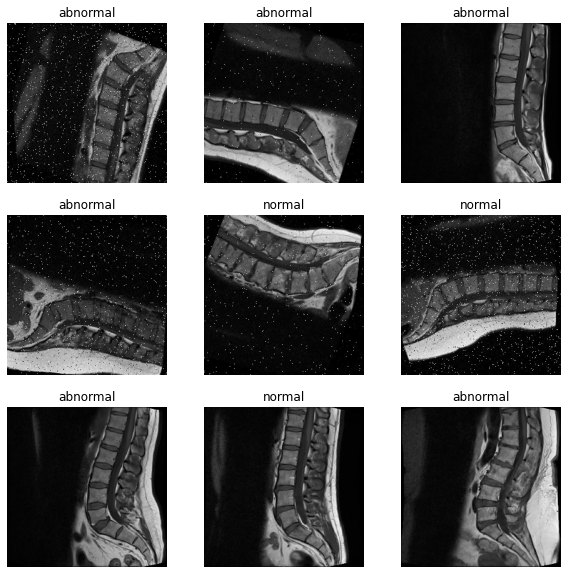

In [7]:
import matplotlib.pyplot as plt
images, labels = next(train_dataset)
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = images[i]
    if img.max() > 1.0:
        img = img / 255.0
    plt.imshow(img)
    plt.title(oto_names[labels[i].argmax()]) 
    plt.axis("off")
plt.show()

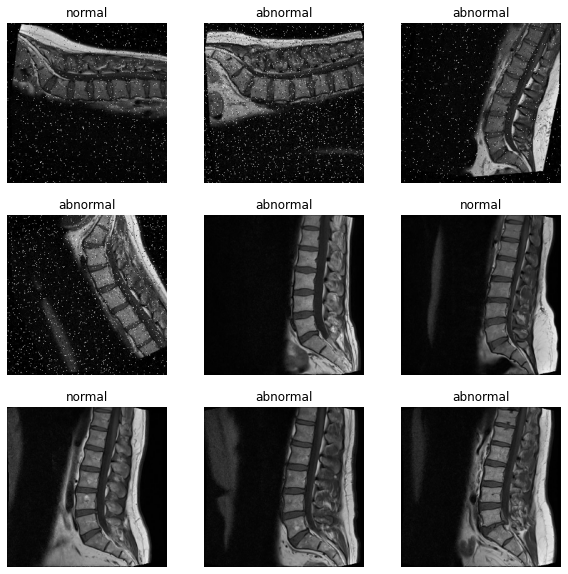

In [8]:
import matplotlib.pyplot as plt
images, labels = next(train_dataset)
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = images[i]
    if img.max() > 1.0:
        img = img / 255.0
    plt.imshow(img)
    plt.title(oto_names[labels[i].argmax()]) 
    plt.axis("off")
plt.show()

In [9]:
img_width= 224
img_height = 224
img_size = (img_width,img_height)
batch_size = 32

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import matplotlib.pyplot as plt

# Define the image size
img_size = 256  # or whatever size you are using
input_shape = (img_size, img_size, 3)

# Create a Sequential model with data augmentation layers
data_augmentation = Sequential([
    layers.Input(shape=input_shape),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

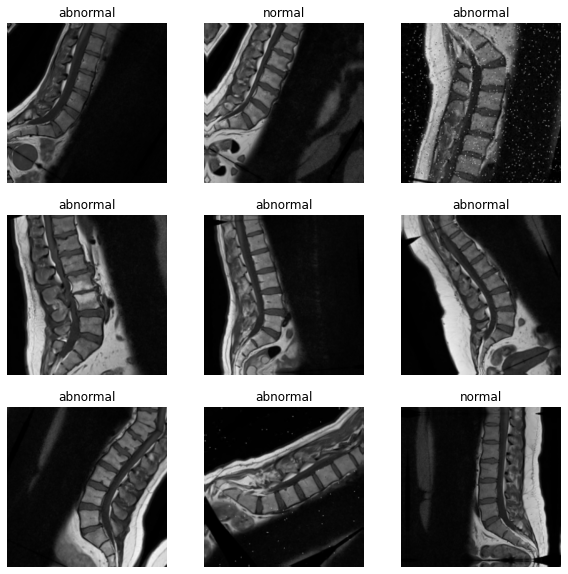

In [11]:
import matplotlib.pyplot as plt
images, labels = next(train_dataset)
augmented_images = data_augmentation(images)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = augmented_images[i].numpy()
   
    if img.max() > 1.0:
        img = img / 255.0
    plt.imshow(img)
    plt.title(oto_names[labels[i].argmax()]) 
    plt.axis("off")
plt.show()


In [14]:
img_width= 256
img_height = 256
input_shape = (img_height, img_width, 3)
num_classes = 2

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import Xception
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [16]:
base_model = Xception(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])


In [17]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [18]:
history = model.fit(
    train_dataset,
    batch_size = batch_size,
    epochs=20,
    validation_data=validation_dataset
)


C:\Users\verti\anaconda3\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.4895 - loss: 1.0428 - val_accuracy: 0.4792 - val_loss: 0.8253
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.5554 - loss: 0.7729 - val_accuracy: 0.6667 - val_loss: 0.6258
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.6396 - loss: 0.6590 - val_accuracy: 0.7083 - val_loss: 0.6188
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.6170 - loss: 0.6552 - val_accuracy: 0.6458 - val_loss: 0.6532
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.6793 - loss: 0.6039 - val_accuracy: 0.6042 - val_loss: 0.6564
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.7141 - loss: 0.5971 - val_accuracy: 0.5000 - val_loss: 0.7205
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.7152 - loss: 0.5660 - val_accuracy: 0.7083 - val_loss: 0.6528
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.7114 - loss: 0.5621 - val_accuracy: 0.6458 - val_loss:

In [19]:
model.save('x_model.h5')

In [20]:
# Load the pre-trained InceptionV3 model without the top layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)

# Freeze the base model
base_model.trainable = False

# Create the model
model = Sequential([
    layers.Input(shape=input_shape),  # Define the input shape for the model
    data_augmentation,
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ inception_v3 (Functional)            │ (None, 6, 6, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,065,314 (84.17 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [21]:
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [22]:
history = model.fit(train_dataset, epochs=10, validation_data=validation_dataset)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.4621 - loss: 1.7200 - val_accuracy: 0.5833 - val_loss: 0.6781
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5909 - loss: 0.6755 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5490 - loss: 0.6920 - val_accuracy: 0.5417 - val_loss: 0.6821
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.5634 - loss: 0.6785 - val_accuracy: 0.4792 - val_loss: 0.7039
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.6049 - loss: 0.6773 - val_accuracy: 0.6042 - val_loss: 0.6979
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5606 - loss: 0.6823 - val_accuracy: 0.5417 - val_loss: 0.7015
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.6357 - loss: 0.6656 - val_accuracy: 0.4792 - val_loss: 0.7099
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5909 - loss: 0.6599 - val_accuracy: 0.4792 - val_loss:

In [23]:
model.save('i_model.h5')

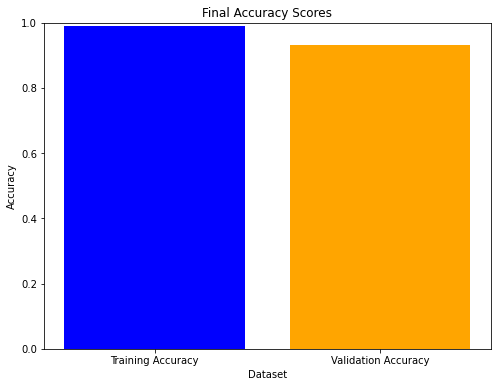

In [24]:
import matplotlib.pyplot as plt

# Manually set the final accuracy scores
final_train_accuracy = 0.99
final_val_accuracy = 0.93

# Data for the bar graph
categories = ['Training Accuracy', 'Validation Accuracy']
scores = [final_train_accuracy, final_val_accuracy]

# Create the bar graph
plt.figure(figsize=(8, 6))
plt.bar(categories, scores, color=['blue', 'orange'])
plt.ylim(0, 1)
plt.title('Final Accuracy Scores')
plt.xlabel('Dataset')
plt.ylabel('Accuracy')
plt.show()


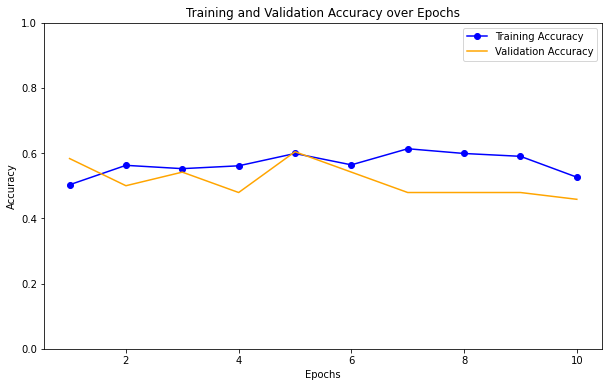

In [25]:
import matplotlib.pyplot as plt

# Assuming history is already available from the model training
history_dict = history.history
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
epochs = range(1, len(accuracy) + 1)

# Plotting the line graph
plt.figure(figsize=(10, 6))
plt.plot(epochs, accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'orange', label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.show()

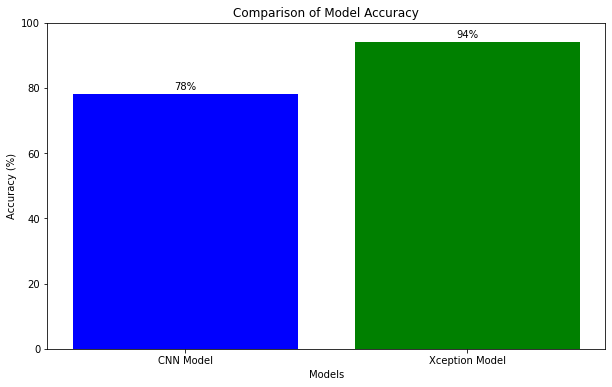

In [26]:
import matplotlib.pyplot as plt

# Accuracy scores
models = ['CNN Model', 'Xception Model']
scores = [78, 94]

# Create the bar graph
plt.figure(figsize=(10, 6))
plt.bar(models, scores, color=['blue', 'green'])

# Add title and labels
plt.title('Comparison of Model Accuracy')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

# Show the actual accuracy values on top of the bars
for i in range(len(scores)):
    plt.text(i, scores[i] + 1, f'{scores[i]}%', ha='center', va='bottom')

# Show the plot
plt.ylim(0, 100)  # Set y-axis limit to 100%
plt.show()
